# Quantum General Adversial Networks
The notebook implements QGAN compatible with following the code in Pennylane tutorial: https://pennylane.ai/qml/demos/tutorial_quantum_gans.
The code is tweaked to be compatible for training on Metal Performance Shaders (MPS) backend.
In addition, the following changes are done to achieve better results:
- Initial state is encoded using Rx gates instead of Ry gates used in tutorial
- The generator is updated once for every 3 gradient steps of the discriminator.
- The learning rate of discriminator is relative to generator's learning rate by factor of 0.01.


### Training results from tutorial:
<img width="80%" src="./tutorial_training.png">
<br/>
<br/>

### Training results from this notebook:
<img width="80%" src="./output.png">





In [41]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pennylane as qml

# Pytorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.set_default_dtype(torch.float32)


In [42]:
class DigitsDataset(Dataset):
    """Pytorch dataloader for the Optical Recognition of Handwritten Digits Data Set"""

    def __init__(self, csv_file, label=0, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.label = label
        self.csv_file = csv_file
        self.transform = transform
        self.df = self.filter_by_label(label)

    def filter_by_label(self, label):
        # Use pandas to return a dataframe of only zeros
        df = pd.read_csv(self.csv_file)
        df = df.loc[df.iloc[:, -1] == label]
        return df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        image = self.df.iloc[idx, :-1] / 16
        image = np.array(image)
        image = image.astype(np.float32).reshape(8, 8)

        if self.transform:
            image = self.transform(image)

        # Return image and label
        return image, self.label

In [43]:
image_size = 8  # Height / width of the square images
batch_size = 1

transform = transforms.Compose([transforms.ToTensor()])
dataset = DigitsDataset(csv_file="handwritten/optdigits.tra", label=0, transform=transform)
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True, drop_last=True
)

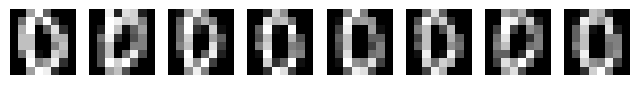

In [44]:
plt.figure(figsize=(8,2))

for i in range(8):
    image = dataset[i][0].reshape(image_size,image_size)
    plt.subplot(1,8,i+1)
    plt.axis('off')
    plt.imshow(image.numpy(), cmap='gray')

plt.show()


In [45]:
class Discriminator(nn.Module):
    """Fully connected classical discriminator"""

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Inputs to first hidden layer (num_input_features -> 64)
            nn.Linear(image_size * image_size, 64),
            nn.ReLU(),
            # First hidden layer (64 -> 16)
            nn.Linear(64, 16),
            nn.ReLU(),
            # Second hidden layer (16 -> output)
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x).to(device)

In [46]:
n_qubits = 5  # Total number of qubits / N
n_a_qubits = 1  # Number of ancillary qubits / N_A
q_depth = 6  # Depth of the parameterised quantum circuit / D
n_generators = 4  # Number of subgenerators for the patch method / N_G

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dev = qml.device("lightning.qubit", wires=n_qubits)

In [47]:
@qml.qnode(dev, diff_method="parameter-shift")
def quantum_circuit(noise, weights):

    weights = weights.reshape(q_depth, n_qubits)

    # Initialise latent vectors
    for i in range(n_qubits):
        qml.RX(noise[i], wires=i)

    # Repeated layer
    for i in range(q_depth):
        # Parameterised layer
        for y in range(n_qubits):
            qml.RY(weights[i][y], wires=y)

        # Control Z gates
        for y in range(n_qubits - 1):
            qml.CZ(wires=[y, y + 1])


    return qml.probs(wires=list(range(n_qubits)))

def partial_measure(noise, weights):
    # Non-linear Transform
    probs = quantum_circuit(noise, weights)
    probsgiven0 = probs[: (2 ** (n_qubits - n_a_qubits))]
    probsgiven0 /= torch.sum(probs)

    # Post-Processing
    probsgiven = probsgiven0 / torch.max(probsgiven0)
    return probsgiven

In [48]:
class PatchQuantumGenerator(nn.Module):
    """Quantum generator class for the patch method"""

    def __init__(self, n_generators, q_delta=1):
        """
        Args:
            n_generators (int): Number of sub-generators to be used in the patch method.
            q_delta (float, optional): Spread of the random distribution for parameter initialisation.
        """

        super().__init__()

        self.q_params = nn.ParameterList(
            [
                nn.Parameter((q_delta * torch.rand(q_depth * n_qubits)), requires_grad=True)
                for _ in range(n_generators)
            ]
        )
        self.n_generators = n_generators


    def forward(self, x):
        # Size of each sub-generator output
        patch_size = 2 ** (n_qubits - n_a_qubits)

        # Create a Tensor to 'catch' a batch of images from the for loop. x.size(0) is the batch size.
        images = torch.zeros(x.size(0), 0, device=x.device)

        # Iterate over all sub-generators
        for params in self.q_params:
            # Create a Tensor to 'catch' a batch of the patches from a single sub-generator
            patches = torch.zeros(0, patch_size, device=x.device)
            for elem in x:
                elemclone = elem.clone().cpu()
                paramsclone = params.clone().cpu()
                q_out = partial_measure(elemclone, paramsclone)
                # Move result back to the appropriate device
                q_out = q_out.float().unsqueeze(0).to(x.device)
                patches = torch.cat((patches, q_out))

            # Each batch of patches is concatenated with each other to create a batch of images
            images = torch.cat((images, patches), 1)

        return images

In [49]:
lrG = 0.3  # Learning rate for the generator
lrD = lrG*0.01  # Learning rate for the discriminator, relative to generator
num_iter = 500  # Number of training iterations
discriminator = Discriminator().to(device)
generator = PatchQuantumGenerator(n_generators).to(device)

# Binary cross entropy
criterion = nn.BCELoss()

# Optimisers
optD = optim.SGD(discriminator.parameters(), lr=lrD)
optG = optim.SGD(generator.parameters(), lr=lrG)

real_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
fake_labels = torch.full((batch_size,), 0.0, dtype=torch.float, device=device)

# Fixed noise allows us to visually track the generated images throughout training
fixed_noise = torch.rand(8, n_qubits, device=device, dtype=torch.float32) * math.pi / 2

# Iteration counter
counter = 0

# Collect images for plotting later
results = []
resultsorginal = []

while True:
    for i, (data, _) in enumerate(dataloader):

        # Data for training the discriminator
        data = data.reshape(-1, image_size * image_size)
        real_data = data.to(device)

        # Noise following a uniform distribution in range [0,pi/2)
        noise = torch.rand(batch_size, n_qubits, device=device, dtype=torch.float32) * math.pi / 2
        fake_data = generator(noise)

        # Training the discriminator thrice
        for _ in range(3):
            discriminator.zero_grad()
            outD_real = discriminator(real_data).view(-1)
            outD_fake = discriminator(fake_data.detach()).view(-1)

            errD_real = criterion(outD_real, real_labels)
            errD_fake = criterion(outD_fake, fake_labels)
            # Propagate gradients
            errD_real.backward()
            errD_fake.backward()

            errD = errD_real + errD_fake
            optD.step()

        # Training the generator
        generator.zero_grad()
        outD_fake = discriminator(fake_data).view(-1)
        errG = criterion(outD_fake, real_labels)
        errG.backward()
        optG.step()

        counter += 1

        # Show loss values
        if counter % 10 == 0:
            print(f'Iteration: {counter}, Discriminator Loss: {errD:0.3f}, Generator Loss: {errG:0.3f}')
            test_images = generator(fixed_noise).view(8,1,image_size,image_size).cpu().detach()

            # Save images every 50 iterations
            if counter % 50 == 0:
                results.append(test_images)

        if counter == num_iter:
            break
    if counter == num_iter:
        break

Iteration: 10, Discriminator Loss: 1.347, Generator Loss: 0.607
Iteration: 20, Discriminator Loss: 1.336, Generator Loss: 0.613
Iteration: 30, Discriminator Loss: 1.326, Generator Loss: 0.611
Iteration: 40, Discriminator Loss: 1.292, Generator Loss: 0.639
Iteration: 50, Discriminator Loss: 1.299, Generator Loss: 0.645
Iteration: 60, Discriminator Loss: 1.275, Generator Loss: 0.652
Iteration: 70, Discriminator Loss: 1.270, Generator Loss: 0.658
Iteration: 80, Discriminator Loss: 1.248, Generator Loss: 0.658
Iteration: 90, Discriminator Loss: 1.209, Generator Loss: 0.692
Iteration: 100, Discriminator Loss: 1.241, Generator Loss: 0.678
Iteration: 110, Discriminator Loss: 1.242, Generator Loss: 0.667
Iteration: 120, Discriminator Loss: 1.222, Generator Loss: 0.705
Iteration: 130, Discriminator Loss: 1.220, Generator Loss: 0.687
Iteration: 140, Discriminator Loss: 1.128, Generator Loss: 0.747
Iteration: 150, Discriminator Loss: 1.105, Generator Loss: 0.783
Iteration: 160, Discriminator Loss

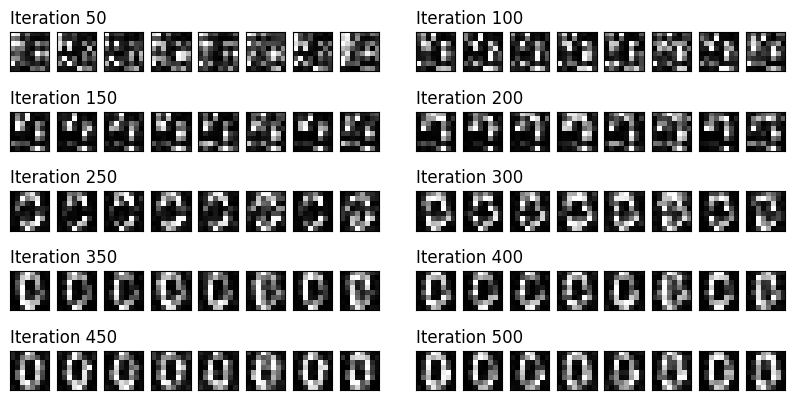

In [51]:
fig = plt.figure(figsize=(10, 5))
outer = gridspec.GridSpec(5, 2, wspace=0.1)

for i, images in enumerate(results):
    inner = gridspec.GridSpecFromSubplotSpec(1, images.size(0),
                    subplot_spec=outer[i])
    images = torch.squeeze(images, dim=1)
    for j, im in enumerate(images):

        ax = plt.Subplot(fig, inner[j])
        ax.imshow(im.numpy(), cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        if j==0:
            ax.set_title(f'Iteration {50+i*50}', loc='left')
        fig.add_subplot(ax)

plt.show()